In [3]:
import sys
!{sys.executable} -m pip install matplotlib seaborn statsmodels scikit-learn openpyxl

You should consider upgrading via the 'c:\Users\usuario\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
# Librerías utilizadas


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

In [5]:

base_path = Path.cwd()

prestamos = pd.read_excel(base_path / "datos" / "datos_limpio_automovil.xlsx")
prestamos.head(5)

,Unnamed: 0,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,...,Estudios_Escolar,Estudios_Grado Universitario,Estudios_Máster,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,0,O77MPJ,26,19153,6973,706,9,1,19.05,36,...,False,True,False,False,False,True,False,False,False,True
1,8,IYOL1S,29,39531,40000,826,0,1,9.74,24,...,False,False,False,False,False,True,False,True,False,False
2,9,FRMZVN,29,40348,16448,740,9,1,14.73,24,...,False,False,True,False,False,True,False,False,False,True
3,26,YKHXVY,38,41732,42040,661,173,2,13.24,48,...,False,True,False,False,False,False,True,True,False,False
4,32,NHDJTK,35,35085,16406,759,181,1,9.74,36,...,True,False,False,False,False,True,False,True,False,False


In [6]:
print("Número de observaciones por clase") 
print(prestamos['Impago'].value_counts())
print("")

print("Porcentaje de observaciones por clase")
print(100 * prestamos['Impago'].value_counts(normalize=True))

Número de observaciones por clase
Impago
0    68038
1     8886
Name: count, dtype: int64

Porcentaje de observaciones por clase
Impago
0    88.448339
1    11.551661
Name: proportion, dtype: float64


Observamos que el 88.45% de préstamos han sido pagados

In [7]:
prestamos.describe()

,Unnamed: 0,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima
count,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000
mean,255090.200783,39.654789,41536.575555,44730.183922,692.082757,212.577557,2.001885,10.652821,37.260309,0.319806,0.350710,0.448963,0.301258,0.115517,383.694225
std,147256.705977,10.088582,16014.092493,46407.624924,87.772342,150.346325,1.002854,3.813562,14.154771,0.181095,0.477195,0.497392,0.458808,0.319646,267.385642
min,0.000000,19.000000,16000.000000,3000.000000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,10.000000
25%,128111.750000,33.000000,30503.750000,14940.750000,635.000000,70.000000,1.000000,7.930000,24.000000,0.140000,0.000000,0.000000,0.000000,0.000000,137.130000
50%,255081.500000,40.000000,39159.000000,40000.000000,703.000000,208.000000,2.000000,10.550000,36.000000,0.290000,0.000000,0.000000,0.000000,0.000000,332.670000
75%,382469.500000,46.000000,50100.000000,46480.000000,761.000000,337.000000,3.000000,13.240000,48.000000,0.550000,1.000000,1.000000,1.000000,0.000000,610.615000
max,510700.000000,64.000000,120000.000000,400000.000000,845.000000,622.000000,4.000000,24.440000,60.000000,0.550000,1.000000,1.000000,1.000000,1.000000,800.000000


In [8]:

X = prestamos.drop(columns = ['Impago', 'Unnamed: 0', 'ID', 'Prima',
                              'Estudios_Escolar', 'Tipo_Jornada_Laboral_Jornada completa',
                              'Estado_Civil_Casado'])
y = prestamos['Impago']

X_train, X_test, y_train, y_test = train_test_split(
                                        X, y.values,
                                        train_size   = 0.8,
                                        random_state = 42,
                                        shuffle      = True,
                                        stratify     = y)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

In [10]:
modelo_log_sklearn = LogisticRegression()
modelo_log_sklearn.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
print("Intercept:", modelo_log_sklearn.intercept_)
print("Coeficiente:", list(zip(X.columns, modelo_log_sklearn.coef_.flatten(), )))
print("Accuracy de entrenamiento:", modelo_log_sklearn.score(X_train_scaled, y_train))

Intercept: [-2.22906909]
Coeficiente: [('Edad', np.float64(-0.33689832458325963)), ('Ingresos', np.float64(0.02539381060963183)), ('Monto_Inicial', np.float64(-0.010294413869774813)), ('Scoring_Crediticio', np.float64(-0.12367848641713405)), ('Meses_Empleo', np.float64(-0.2700818042447094)), ('Num_Creditos', np.float64(-0.0004310250911826101)), ('Ratio_Interes', np.float64(0.41181691721177993)), ('Duracion', np.float64(-0.0221235206408809)), ('Ratio_Deuda_Ingresos', np.float64(-0.05736376249000219)), ('Posesion_Hipoteca', np.float64(0.02349229238681533)), ('Personas_Cargo', np.float64(0.0044150696300517015)), ('Fiador', np.float64(-0.0008328970050532388)), ('Estudios_Doctorado', np.float64(-0.03899089103891511)), ('Estudios_Grado Universitario', np.float64(-0.03373939682008503)), ('Estudios_Máster', np.float64(-0.04752783726287588)), ('Tipo_Jornada_Laboral_Autónomo', np.float64(0.023193095457393818)), ('Tipo_Jornada_Laboral_Desempleado', np.float64(-0.0038595713950660237)), ('Tipo_Jorn

In [12]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

predicciones = modelo_log_sklearn.predict_proba(X = X_test_scaled)
predicciones = pd.DataFrame(predicciones, columns = modelo_log_sklearn.classes_)
predicciones.head()

,0,1
0,0.927496,0.072504
1,0.781836,0.218164
2,0.923281,0.076719
3,0.862410,0.137590
4,0.847159,0.152841


In [13]:
predicciones = modelo_log_sklearn.predict(X_test_scaled)
predicciones[:5]

array([0, 0, 0, 0, 0])

In [14]:
print("Predicciones de impago (1):", (predicciones == 1).sum())
print("Predicciones de no impago (0):", (predicciones == 0).sum())

Predicciones de impago (1): 7
Predicciones de no impago (0): 15378


In [15]:
X_train_scaled = sm.add_constant(X_train_scaled, prepend=True)
modelo_log_statsm = sm.Logit(endog= y_train, exog = X_train_scaled)
modelo_log_statsm = modelo_log_statsm.fit()
print(modelo_log_statsm.summary())

Optimization terminated successfully.
         Current function value: 0.333513
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                61539
Model:                          Logit   Df Residuals:                    61518
Method:                           MLE   Df Model:                           20
Date:                Mon, 05 Oct 2026   Pseudo R-squ.:                 0.06815
Time:                        15:24:44   Log-Likelihood:                -20524.
converged:                       True   LL-Null:                       -22025.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -2.2298      0.015 

In [16]:
intervalos_ci = modelo_log_statsm.conf_int(alpha=0.05).rename(columns={0: "2.5%", 1: "97.5%"})

intervalos_ci[:4]

,2.5%,97.5%
const,-2.258778,-2.200744
Edad,-0.446010,-0.226614
Ingresos,-0.026072,0.080435
Monto_Inicial,-0.051378,0.027115


In [17]:
X_test_scaled = sm.add_constant(X_test_scaled, has_constant='add')

predicciones = modelo_log_statsm.predict(exog = X_test_scaled)
predicciones[:4]

50731    0.072409
44077    0.218069
33401    0.076888
57216    0.137263
dtype: float64

In [18]:
clasificacion = np.where(predicciones<0.5, 0, 1)
clasificacion[:4]

array([0, 0, 0, 0])

In [19]:
from sklearn.metrics import accuracy_score

acierto = accuracy_score(y_test, clasificacion)
error = 1 - acierto
print("Acierto:", round(acierto*100, 2), "%")
print("Error:", round(error*100, 2), "%")

Acierto: 88.42 %
Error: 11.58 %


In [20]:


from sklearn.metrics import classification_report

print(classification_report(y_test, clasificacion))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     13608
           1       0.14      0.00      0.00      1777

    accuracy                           0.88     15385
   macro avg       0.51      0.50      0.47     15385
weighted avg       0.80      0.88      0.83     15385



[[13602     6]
 [ 1776     1]]


<Axes: >

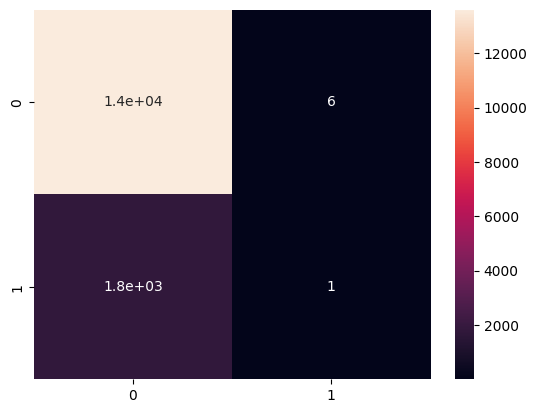

In [21]:

from sklearn.metrics import confusion_matrix

c_matrix = confusion_matrix(y_test, clasificacion)
print(c_matrix)

sns.heatmap(c_matrix, annot=True)

In [22]:
from sklearn.metrics import precision_recall_curve

# Primero creamos una tabla para ver como varía la precisión y recall en función del valor umbral

prec, rec, thresholds = precision_recall_curve(y_test, predicciones) # necesitamos la probabilidad de la clase 1
pd.DataFrame({"prec":prec[:-1], "rec":rec[:-1], "threshold":thresholds})[80:100]


,prec,rec,threshold
80,0.115975,0.998875,0.017935
81,0.115983,0.998875,0.017957
82,0.115990,0.998875,0.018041
83,0.115998,0.998875,0.018109
84,0.116005,0.998875,0.018112
85,0.116013,0.998875,0.018213
86,0.116021,0.998875,0.018272
87,0.116028,0.998875,0.018290
88,0.116036,0.998875,0.018308
89,0.116043,0.998875,0.018330


Text(0.5, 1.0, 'PR Curve')

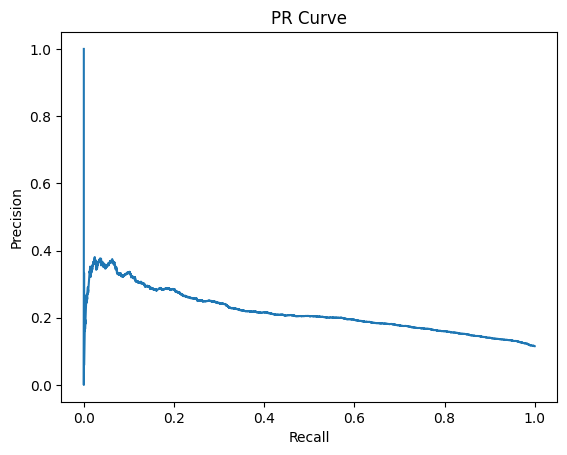

In [23]:

plt.plot(rec, prec)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("PR Curve")

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, predicciones)
pd.DataFrame({"tpr":tpr, "fpr":fpr, "threshold":threshold})


,tpr,fpr,threshold
0,0.000000,0.000000,inf
1,0.000000,0.000073,0.548955
2,0.000000,0.000147,0.536615
3,0.000563,0.000147,0.533421
4,0.000563,0.001176,0.439505
...,...,...,...
3040,0.998875,0.997208,0.015730
3041,0.999437,0.997208,0.015685
3042,0.999437,0.998530,0.014811
3043,1.000000,0.998530,0.014782


Text(0.5, 1.0, 'Curva ROC')

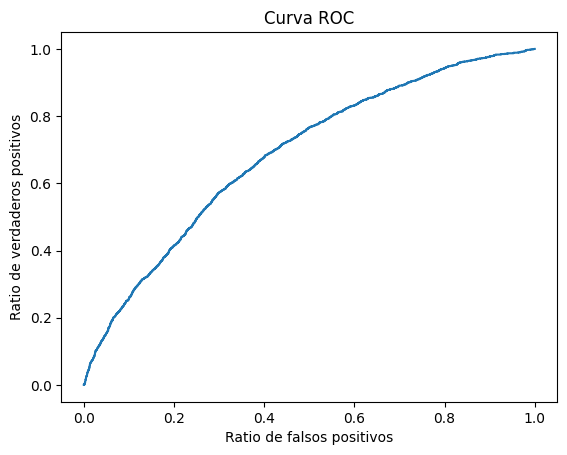

In [25]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)

plt.xlabel("Ratio de falsos positivos")
plt.ylabel("Ratio de verdaderos positivos")
plt.title("Curva ROC")